## Constants
- land-sea mask
- orography
## Surface Variabels
- two meter temperature
- total column water vapor

In [20]:
import netCDF4 as nc
import healpy as hp
import numpy as np
from scipy.interpolate import griddata

In [21]:
dataset = nc.Dataset('/Users/annelouisedeboer/Desktop/Thesis_prep/dlwp-hpx/src/dlwp-hpx/data/era5_z500.nc', 'r')

In [22]:
dataset

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    CDI: Climate Data Interface version 2.1.0 (https://mpimet.mpg.de/cdi)
    Conventions: CF-1.6
    history: Tue Nov 22 07:21:36 2022: cdo -b F32 mergetime 1979-2021_era5_1deg_3h_geopotential_500_p0.nc 1979-2021_era5_1deg_3h_geopotential_500_p1.nc 1979-2021_era5_1deg_3h_geopotential_500.nc
2022-10-27 23:47:30 GMT by grib_to_netcdf-2.25.1: /opt/ecmwf/mars-client/bin/grib_to_netcdf.bin -S param -o /cache/data9/adaptor.mars.internal-1666913232.3154385-28517-1-07242098-fb0a-498f-9e07-2bc046b9f5fe.nc /cache/tmp/07242098-fb0a-498f-9e07-2bc046b9f5fe-adaptor.mars.internal-1666910096.397881-28517-1-tmp.grib
    CDO: Climate Data Operators version 2.1.0 (https://mpimet.mpg.de/cdo)
    dimensions(sizes): time(16), longitude(360), latitude(181), level(1)
    variables(dimensions): int32 time(time), float32 longitude(longitude), float32 latitude(latitude), float32 level(level), float32 z(time, level, latitude, longitude)

In [23]:
dataset.variables['time']

<class 'netCDF4.Variable'>
int32 time(time)
    standard_name: time
    long_name: time
    axis: T
    units: hours since 1900-01-01
    calendar: gregorian
unlimited dimensions: time
current shape = (16,)
filling on, default _FillValue of -2147483647 used

In [24]:
lats = dataset.variables['latitude'][:]
lons = dataset.variables['longitude'][:]
levels = dataset.variables['level'][:]
times = dataset.variables['time'][:]
z = dataset.variables['z'][:]

In [25]:
time_index = 10
level_index = 0
data = z[time_index, level_index, :, :]

In [26]:
nside = 128  # Choose an appropriate HEALPix resolution
npix = hp.nside2npix(nside)

# Create arrays of HEALPix pixel coordinates
theta, phi = hp.pix2ang(nside, np.arange(npix))

# Convert to lat/lon in degrees
hp_lats = 90 - np.degrees(theta)
hp_lons = np.degrees(phi)

# Create a 2D grid of the original lat/lon coordinates
lons_grid, lats_grid = np.meshgrid(lons, lats)

# Interpolate the original data onto the HEALPix grid
healpix_map = griddata((lons_grid.flatten(), lats_grid.flatten()), data.flatten(), (hp_lons, hp_lats), method='linear')

In [34]:
print(len(data.flatten()))
print(len(lons_grid.flatten()))

65160
65160


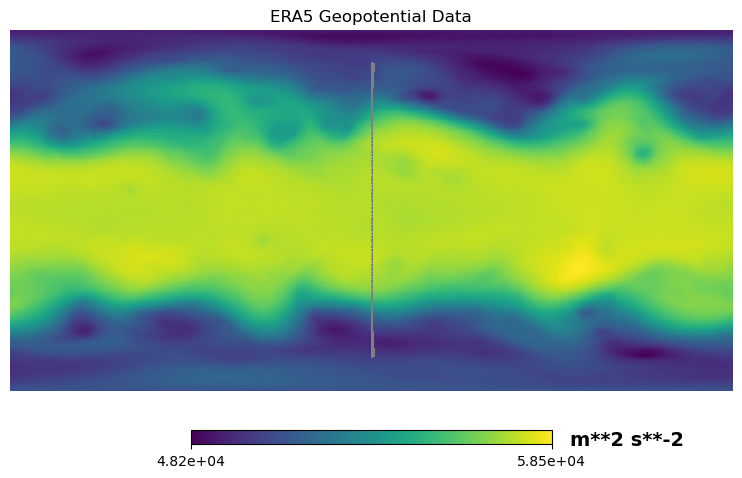

In [42]:
hp.cartview(healpix_map, title="ERA5 Geopotential Data", unit="m**2 s**-2")

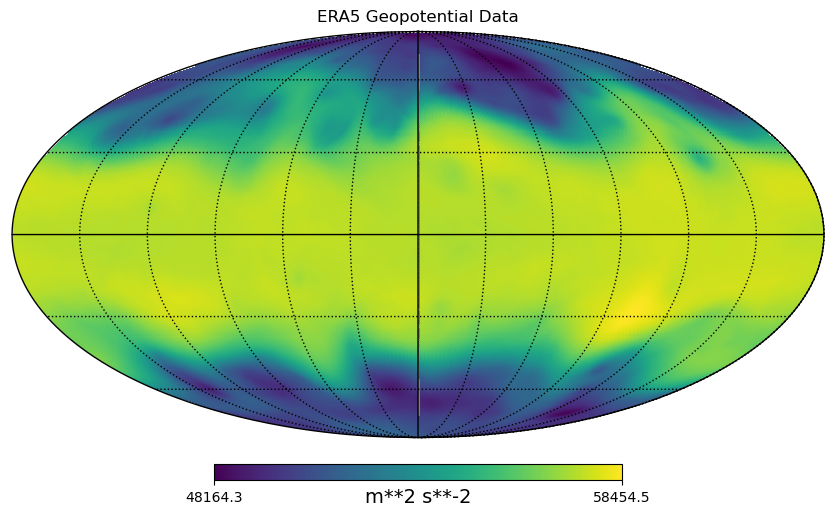

In [35]:
hp.mollview(healpix_map, title="ERA5 Geopotential Data", unit="m**2 s**-2")
hp.graticule()


In [ ]:
#import healpix format data: /Users/annelouisedeboer/Desktop/Thesis_prep/dlwp-hpx/src/dlwp-hpx/era5_1deg_3h_HPX32_1979-2018_z500.nc

In [41]:
# Load the NetCDF file
file_path = '/Users/annelouisedeboer/Desktop/Thesis_prep/dlwp-hpx/src/dlwp-hpx/era5_1deg_3h_HPX32_1979-2018_z500.nc'
 # Load .nc file in HEALPix format to get nside information and to initialize the remapper module
import xarray as xr

latitudes=181,
longitudes=360,
nside=32
fc_ds_hpx = xr.open_dataset(file_path)
fc_ds_hpx # face: 12 height: 32 width: 32 sample: 16 level: 1

<xarray.Dataset> Size: 984kB
Dimensions:  (face: 12, height: 32, width: 32, sample: 16, level: 1)
Coordinates:
  * sample   (sample) datetime64[ns] 128B 2018-01-01 ... 2018-01-02T21:00:00
  * level    (level) float32 4B 500.0
  * face     (face) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * height   (height) int64 256B 0 1 2 3 4 5 6 7 8 ... 24 25 26 27 28 29 30 31
  * width    (width) int64 256B 0 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30 31
Data variables:
    lat      (face, height, width) float64 98kB ...
    lon      (face, height, width) float64 98kB ...
    z        (sample, level, face, height, width) float32 786kB ...
Attributes:
    CDI:          Climate Data Interface version 2.1.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue Nov 22 07:21:36 2022: cdo -b F32 mergetime 1979-2021_er...
    CDO:          Climate Data Operators version 2.1.0 (https://mpimet.mpg.de...